# Warm-up: Pandas & Seaborn

This workbook serves as an intro to pandas and seaborn you need to *start* Lab 2. It is not a 1-to-1 mirror of the lab assignment, so we expect you to do some self study by yourself. Feel free to use the documentation of pandas, seaborn and google for Lab2 exercises that will push you to do some tinkering.

## Introduction

We will be using a dummy dataset for this tutorial, representing the information of the attendees at a language school. 

The school has 6 columns:

- **Track:** Course tier. **1** = Premium, **2** = Standard, **3** = Budget.
- **Sex:** Student's sex.
- **Age:** Student's age.
- **Fee:** Price paid for attending the school, in US dollars.
- **Passed:** Whether or not the student passed the exam. 1 represents pass, 0 represents failure.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Basics of Pandas 

Let's load and take a peek at the dataset first. We first need to load the csv file into a pandas dataframe with the pandas.read_csv() command.

In [3]:
df = pd.read_csv("students.csv")   
df.head()                          # Prints first 5 rows of the dataframe by default, unless one specificies the row count inside paranthesis.

,Track,Sex,Age,Fee,Passed
0,3,female,NaN,8.50,1
1,2,female,43.0,104.52,0
2,1,female,39.0,134.62,0
3,1,female,54.0,40.01,1
4,3,male,43.0,14.90,0


We can also use df.describe() and df.info() to print some statistics of the columns and the datatypes.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Track   300 non-null    int64  
 1   Sex     300 non-null    str    
 2   Age     237 non-null    float64
 3   Fee     300 non-null    float64
 4   Passed  300 non-null    int64  
dtypes: float64(2), int64(2), str(1)
memory usage: 13.3 KB


In [5]:
df.describe()

,Track,Age,Fee,Passed
count,300.000000,237.000000,300.000000,300.000000
mean,2.330000,29.966245,50.195633,0.620000
std,0.814439,11.047227,48.924166,0.486197
min,1.000000,10.000000,5.320000,0.000000
25%,2.000000,22.000000,17.835000,0.000000
50%,3.000000,30.000000,30.090000,1.000000
75%,3.000000,37.000000,68.192500,1.000000
max,3.000000,59.000000,361.900000,1.000000


In descriptive data analysis, we are often interested in manipulating particular columns for other tasks, such as feature engineering or data imputation. To select a column in pandas, we can simply use:

In [6]:
df["Age"].head()           # Feel free to remove the .head() method, I used it to save space.

0     NaN
1    43.0
2    39.0
3    54.0
4    43.0
Name: Age, dtype: float64

Or we can also select a slice of the dataset containing more than one column:

In [7]:
df[["Age", "Fee"]].head()   # several columns (double brackets) -> DataFrame

,Age,Fee
0,NaN,8.50
1,43.0,104.52
2,39.0,134.62
3,54.0,40.01
4,43.0,14.90


Let's create a new column now, which will represent the school fee in Euros.

In [8]:
df["Fee_eur"] = df["Fee"] * 0.87   # new column = assign to a new name
df.head()

,Track,Sex,Age,Fee,Passed,Fee_eur
0,3,female,NaN,8.50,1,7.3950
1,2,female,43.0,104.52,0,90.9324
2,1,female,39.0,134.62,0,117.1194
3,1,female,54.0,40.01,1,34.8087
4,3,male,43.0,14.90,0,12.9630


We can also do selection based on conditions. For example, let's select the information of students who are older than 18.

In [9]:
df[df['Age'] > 18]

,Track,Sex,Age,Fee,Passed,Fee_eur
1,2,female,43.0,104.52,0,90.9324
2,1,female,39.0,134.62,0,117.1194
3,1,female,54.0,40.01,1,34.8087
4,3,male,43.0,14.90,0,12.9630
6,3,male,24.0,14.22,0,12.3714
...,...,...,...,...,...,...
290,2,male,29.0,68.09,1,59.2383
291,1,female,22.0,89.46,1,77.8302
292,2,female,25.0,36.56,1,31.8072
295,3,male,27.0,12.73,0,11.0751


The conditions can be chained together as well. Let's select students who are older than 18 **and** who also passed the language exam:

In [10]:
df[(df['Age'] > 18) & (df['Passed'] == 1)] # Beware of double equal sign, which represents equality condition in python. Using '=' will cause an error.

,Track,Sex,Age,Fee,Passed,Fee_eur
3,1,female,54.0,40.01,1,34.8087
7,3,female,31.0,9.74,1,8.4738
10,3,male,34.0,25.38,1,22.0806
11,1,female,35.0,135.82,1,118.1634
13,1,female,29.0,42.12,1,36.6444
...,...,...,...,...,...,...
284,3,male,44.0,25.59,1,22.2633
288,3,male,52.0,35.81,1,31.1547
290,2,male,29.0,68.09,1,59.2383
291,1,female,22.0,89.46,1,77.8302


Furthermore, we can use the value counts method to print the available values in categorical columns and their occurrence.

In [11]:
print(df["Track"].value_counts())
print()
print(df["Track"].unique()) # Prints the unique values present in a column.
print()
print(df["Track"].nunique()) # Prints the number of. unique values present in a column.

Track
3    165
2     69
1     66
Name: count, dtype: int64

[3 2 1]

3


You can check pandas documentation for further info on column selection based on conditions. For now we move on.

## 2. Missing values

Datasets are never perfect, so quality issues are ever present in everyday data science tasks. Let's now check the missing values in our dataset.

In [12]:
df.head(100)

,Track,Sex,Age,Fee,Passed,Fee_eur
0,3,female,NaN,8.50,1,7.3950
1,2,female,43.0,104.52,0,90.9324
2,1,female,39.0,134.62,0,117.1194
3,1,female,54.0,40.01,1,34.8087
4,3,male,43.0,14.90,0,12.9630
...,...,...,...,...,...,...
95,3,female,NaN,25.39,0,22.0893
96,1,female,NaN,101.09,1,87.9483
97,3,male,NaN,19.93,0,17.3391
98,3,female,16.0,12.24,0,10.6488


In [12]:
df.isnull().head()          # Returns a dataframe of boolean values where True represents a cell with a NaN/null/missing value.

,Track,Sex,Age,Fee,Passed,Fee_eur
0,False,False,True,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False


In [13]:
df.isnull().sum()          # Returns per-column counts of missing values.

Track       0
Sex         0
Age        63
Fee         0
Passed      0
Fee_eur     0
dtype: int64

There are many ways to handle missing values; sometimes we drop the rows containing them, sometimes we fill them with a statistic such as the column's mean or median, or sometimes we replace them with 0. This decision is really dependant on the analysis task and you can understand which method works better for you only through experience.

Let's fill the missing values in Age column with the mean age.

In [14]:
mean_age = df["Age"].mean()
print('Mean Age:', round(mean_age, 1))        # round method just rounds the value given to it to a desired decimal. Here I set it to 1 for readability.

Mean Age: 30.0


In [15]:
df_imputed = df.copy()
df_imputed['Age'] = df["Age"].fillna(mean_age)
df_imputed

,Track,Sex,Age,Fee,Passed,Fee_eur
0,3,female,29.966245,8.50,1,7.3950
1,2,female,43.000000,104.52,0,90.9324
2,1,female,39.000000,134.62,0,117.1194
3,1,female,54.000000,40.01,1,34.8087
4,3,male,43.000000,14.90,0,12.9630
...,...,...,...,...,...,...
295,3,male,27.000000,12.73,0,11.0751
296,1,female,12.000000,126.21,1,109.8027
297,3,male,23.000000,21.90,0,19.0530
298,3,male,16.000000,10.80,0,9.3960


As you can see below, we don't have any missing values in age column now.

In [16]:
print(df.isnull().sum())          # Original dataset
print()
print(df_imputed.isnull().sum())  # Imputed dataset

Track       0
Sex         0
Age        63
Fee         0
Passed      0
Fee_eur     0
dtype: int64

Track      0
Sex        0
Age        0
Fee        0
Passed     0
Fee_eur    0
dtype: int64


One can also drop the rows where missing values exist. Doing this will cost us information though, since we will be dropping the whole row, which may contain some useful information in its cells where there are no missing values.

You can use the dropna() method for this. It doesnt drop the values inplace by default, so don't worry calling it.

In [17]:
df.dropna()

,Track,Sex,Age,Fee,Passed,Fee_eur
1,2,female,43.0,104.52,0,90.9324
2,1,female,39.0,134.62,0,117.1194
3,1,female,54.0,40.01,1,34.8087
4,3,male,43.0,14.90,0,12.9630
6,3,male,24.0,14.22,0,12.3714
...,...,...,...,...,...,...
294,2,female,15.0,76.49,1,66.5463
295,3,male,27.0,12.73,0,11.0751
296,1,female,12.0,126.21,1,109.8027
297,3,male,23.0,21.90,0,19.0530


Or if you want to drop the rows based on a specific column only, instead of the whole dataset:

In [18]:
df_trimmed = df.copy()

df_trimmed = df_trimmed.dropna(subset=['Age']).reset_index(drop=True)

In [19]:
df_trimmed

,Track,Sex,Age,Fee,Passed,Fee_eur
0,2,female,43.0,104.52,0,90.9324
1,1,female,39.0,134.62,0,117.1194
2,1,female,54.0,40.01,1,34.8087
3,3,male,43.0,14.90,0,12.9630
4,3,male,24.0,14.22,0,12.3714
...,...,...,...,...,...,...
232,2,female,15.0,76.49,1,66.5463
233,3,male,27.0,12.73,0,11.0751
234,1,female,12.0,126.21,1,109.8027
235,3,male,23.0,21.90,0,19.0530


## 3. Groupby

Sometimes we may need to compare the data points which fall into different groups vis-a-vis each other. For example, we have three course tiers, represented with the track column. Let's compare the mean fee that the students paid in each group. We can use the groupby command for this:

In [21]:
df.groupby("Track")["Fee"].mean()

Track
1    113.801818
2     59.032754
3     21.057636
Name: Fee, dtype: float64

We can also compare the mean age per track,

In [22]:
df.groupby("Track")["Age"].mean()

Track
1    27.854545
2    30.107143
3    30.825397
Name: Age, dtype: float64

Or the success percentage:

In [23]:
df.groupby("Track")["Passed"].mean()

Track
1    0.848485
2    0.695652
3    0.496970
Name: Passed, dtype: float64

We can also print more than one statistic simultaneously per group:

In [24]:
df.groupby("Track")[["Fee", "Age"]].mean()

,Fee,Age
Track,,
1,113.801818,27.854545
2,59.032754,30.107143
3,21.057636,30.825397


Or more nuanced comparison:

In [25]:
print(df.groupby(["Track", "Sex"])["Fee"].mean())

print()

print(df.groupby(["Track", "Sex"])["Fee"].std()) # Fee standard deviation per track and sex

print()

#print(df.groupby(["Track", "Sex"])["Fee"].median()) # Median fees per track and sex

print()

print(df.groupby(["Track", "Sex"])["Passed"].mean()) # Success rate per track and sex

Track  Sex   
1      female    111.785526
       male      116.538214
2      female     58.142500
       male       60.003939
3      female     21.725581
       male       20.330506
Name: Fee, dtype: float64

Track  Sex   
1      female    65.876648
       male      46.931361
2      female    35.256334
       male      26.321804
3      female    10.921990
       male       9.352996
Name: Fee, dtype: float64


Track  Sex   
1      female    0.868421
       male      0.821429
2      female    0.722222
       male      0.666667
3      female    0.523256
       male      0.468354
Name: Passed, dtype: float64


## 4. Plotting with seaborn

Most seaborn functions share one pattern:

`sns.<plot>(data=<DataFrame>, x="<column>", y="<column>", hue="<column that sets the colour>")`.

Once you know this pattern, the plot types (histograms, boxplots, barplots ...) are a documentation lookup away.

For every plot, we need to create its own figure using matplotlib, otherwise two different plots will be drawn into the same figure. Sometimes you may want to do that, sometimes you don't. Again, it depends on your visualization objective. 

Let's see how plotting with seaborn works with an example, where we want to visualize the correlation between Age and Fee columns.

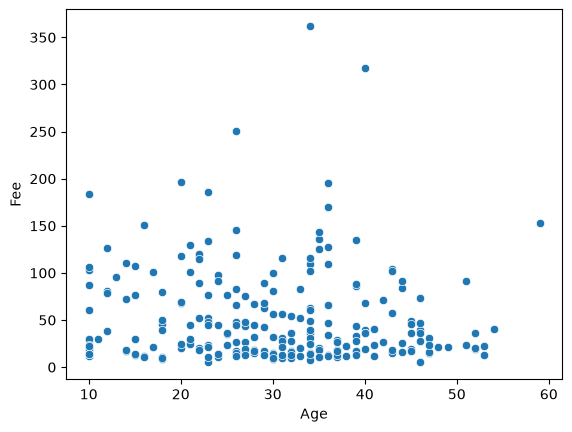

In [26]:
plt.figure()     # start a fresh figure
sns.scatterplot(data=df, x="Age", y="Fee")
plt.show()

Since the dataset we use is a dummy dataset, we don't see a correlation between Age and Fee. In real datasets, it wouldn't be uncommon to see older attendees being able to pay more. But for the sake of simplicity, we won't be spending much time on this.

We can also differentiate our scatter plot above based on the groups, such as Sex or Track.

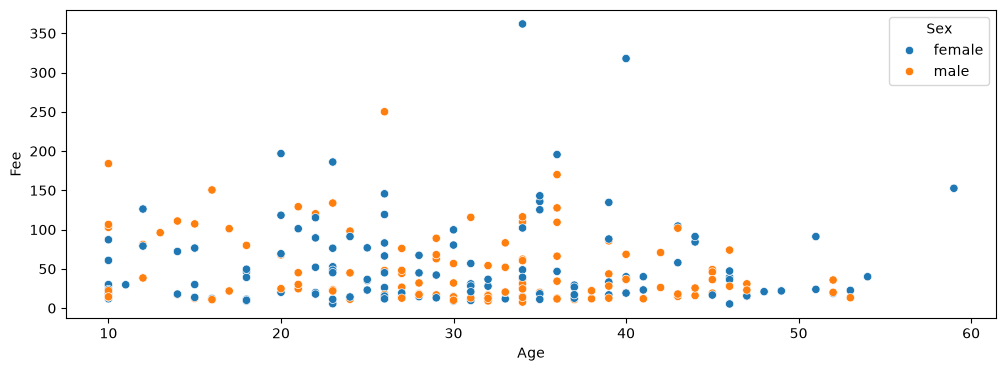

In [27]:
plt.figure(figsize=(12,4)) # You can change the size of the figure with figsize parameter as well. The first value represents width, the second is for height. 
sns.scatterplot(data=df, x="Age", y="Fee", hue='Sex')
plt.show()

Lastly, one can go for more nuanced scatter plots with the help of relplot. Here I will further differentiate the participants by adding their sex to the plots.

<Figure size 1200x400 with 0 Axes>

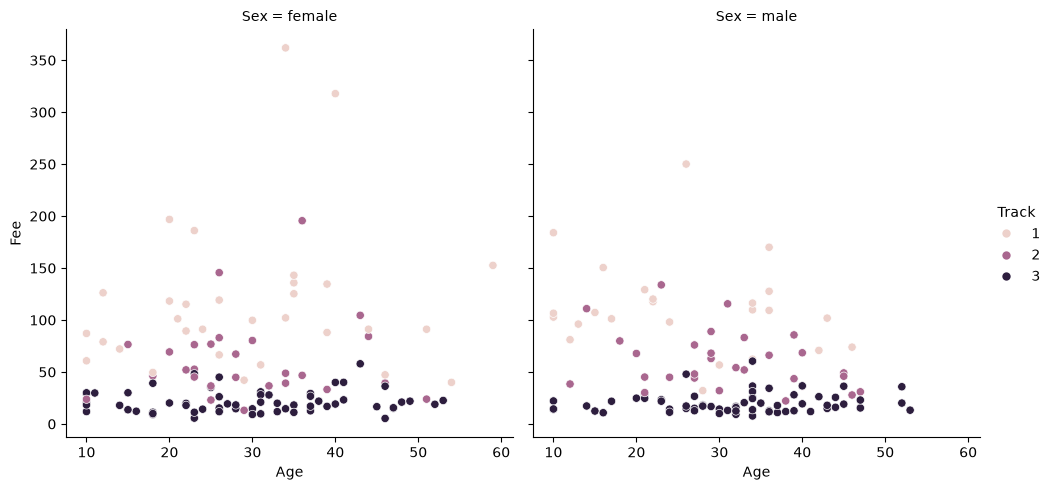

In [28]:
plt.figure(figsize=(12,4))
sns.relplot(data=df, x="Age", y="Fee", col="Sex", hue='Track') # Remember that 1 represents premium courses while 3 is for cheapest ones.
plt.show()

Lastly, let's have a look at the boxplots in seaborn. One doesn't need to use the whole dataset in these plots, we can just slice the Age and Fee columns and draw their boxplot in the same figure.

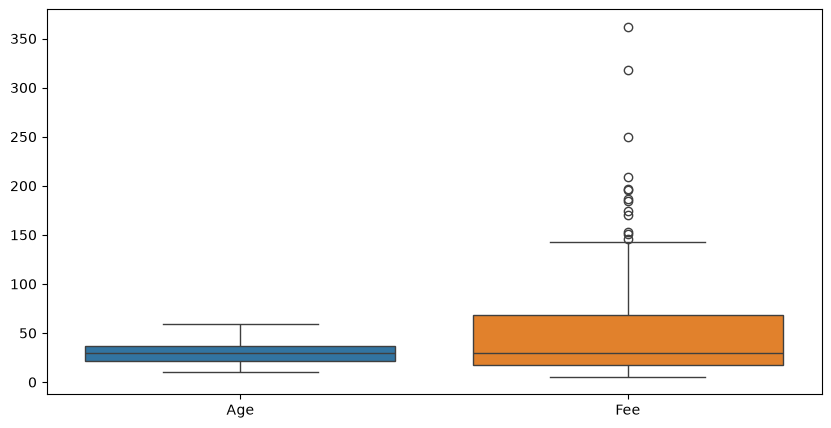

In [29]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[["Age", "Fee"]])
#sns.boxplot(data=df[["Passed"]])    # Uncomment and see what happens to your plots.
plt.show()